In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
data = pd.read_csv("/content/drive/MyDrive/Statistic/weight-height.csv")
data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [7]:
ideal = stats.norm.rvs(size = len(data["Height"]), loc = data["Height"].mean(), scale = data["Height"].std())
ideal

array([65.71746359, 74.52499083, 65.74611423, ..., 69.05374744,
       62.75150837, 68.05828639])

In [8]:
icount, idevision = np.histogram(ideal, bins=100)

In [9]:
count, devision = np.histogram(data["Height"], bins=100)

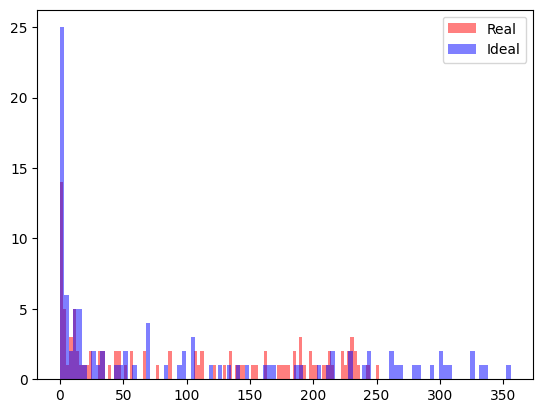

In [12]:
plt.hist(count, color = "red", label = "Real", alpha = 0.5, bins = 100)
plt.hist(icount, color = "blue", label = "Ideal", alpha = 0.5, bins=100)
plt.legend()
plt.show()

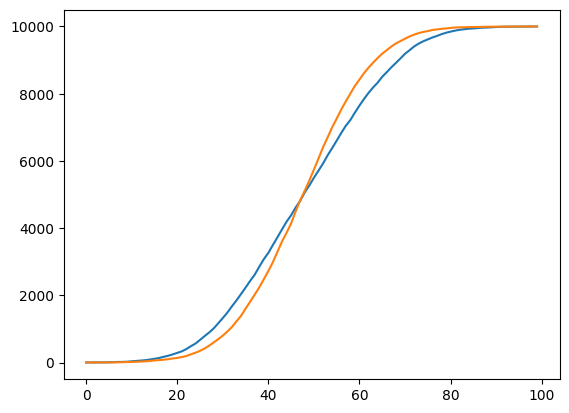

In [13]:
plt.plot(np.cumsum(count))
plt.plot(np.cumsum(icount))
plt.show()

In [14]:
stats.kstest(count, icount)

KstestResult(statistic=np.float64(0.17), pvalue=np.float64(0.11119526053829192), statistic_location=np.int64(235), statistic_sign=np.int8(1))

In [20]:
np.linalg.norm(count, ord=3)

np.float64(703.5652029069142)

In [21]:
def JS(p,q):
  p1 = p / np.linalg.norm(p, ord=1)
  q1 = q / np.linalg.norm(q, ord=1)
  m = (p1 + q1) / 2
  return 0.5 * (stats.entropy(p1, m) + stats.entropy(q1, m))


In [22]:
print(f"Jensonshanon = {JS(count, icount)}")

Jensonshanon = 0.017491772814804997


In [23]:
data2 = pd.read_csv("/content/drive/MyDrive/Statistic/wind_speed_laurel_nebraska.csv")
data2

,10 Min Std Dev,Time,10 Min Sampled Avg
0,2.73,2001-06-11 11:00,22.3
1,1.98,2001-06-11 11:10,23.0
2,1.87,2001-06-11 11:20,23.3
3,2.03,2001-06-11 11:30,22.0
4,3.10,2001-06-11 11:40,20.5
...,...,...,...
216,2.03,2001-06-12 23:00,22.0
217,2.14,2001-06-12 23:10,21.2
218,2.35,2001-06-12 23:20,22.9
219,1.98,2001-06-12 23:30,21.6


In [24]:
ideal2 = stats.norm.rvs(size = len(data2["10 Min Sampled Avg"]), loc = data2["10 Min Sampled Avg"].mean(), scale = data2["10 Min Sampled Avg"].std())

In [25]:
icount2, idevision2 = np.histogram(ideal2, bins=100)
count2, devision2 = np.histogram(data2["10 Min Sampled Avg"], bins=100)

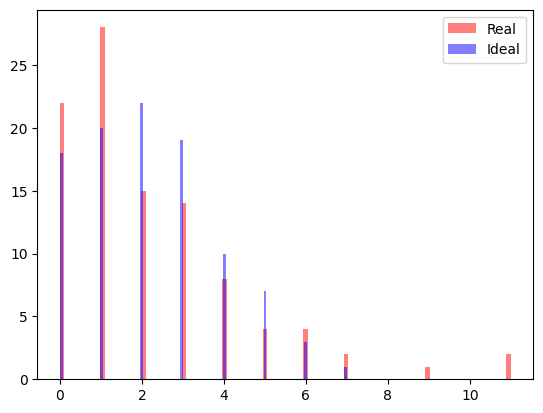

In [26]:
plt.hist(count2, color = "red", label = "Real", alpha = 0.5, bins = 100)
plt.hist(icount2, color = "blue", label = "Ideal", alpha = 0.5, bins=100)
plt.legend()
plt.show()

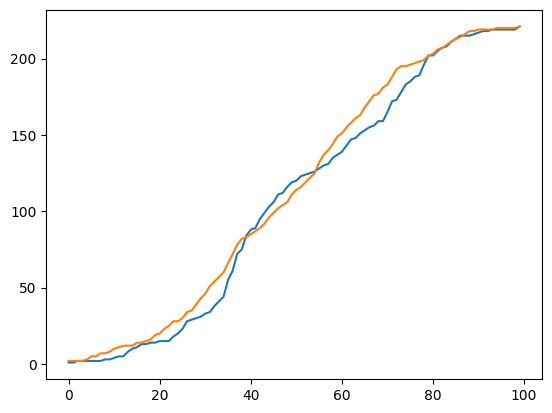

In [27]:
plt.plot(np.cumsum(count2))
plt.plot(np.cumsum(icount2))
plt.show()

In [29]:
print(f"Jensonshanon = {JS(count2, icount2)}")

Jensonshanon = 0.1354099269801714
